## MS Data Analytics Capstone Project: Credit Card Fraud Analysis

**Author:** James Pinkston<br>
**Date:** April xx, 2026

**Introduction:** This capstone project will analyze the detection of fraudulent credit card transactions.

Data Source:  [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

### Import External Python Libraries

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

### Load the dataset and display the first 10 rows.

In [34]:
# Load the credit card fraud detection dataset
fraud_df = pd.read_csv("../data/creditcard.csv")

# Display the first 10 rows
fraud_df.head(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


### Check for missing values and display summary statistics.

In [35]:
# Check for missing values
fraud_df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [36]:
# Display summary statistics
print(fraud_df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.804766e-12 -6.644561e-13 -5.732741e-13  7.602780e-13   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   2.290542e-13  6.119778e-14  3.241911e-14 -5.131429e-13 -7.735050e-13   
std    1.380247e+00  1.332271e+00  1.23709

### Explore data patterns and distributions.

array([[<Axes: xlabel='Time', ylabel='Time'>,
        <Axes: xlabel='Amount', ylabel='Time'>,
        <Axes: xlabel='Class', ylabel='Time'>],
       [<Axes: xlabel='Time', ylabel='Amount'>,
        <Axes: xlabel='Amount', ylabel='Amount'>,
        <Axes: xlabel='Class', ylabel='Amount'>],
       [<Axes: xlabel='Time', ylabel='Class'>,
        <Axes: xlabel='Amount', ylabel='Class'>,
        <Axes: xlabel='Class', ylabel='Class'>]], dtype=object)

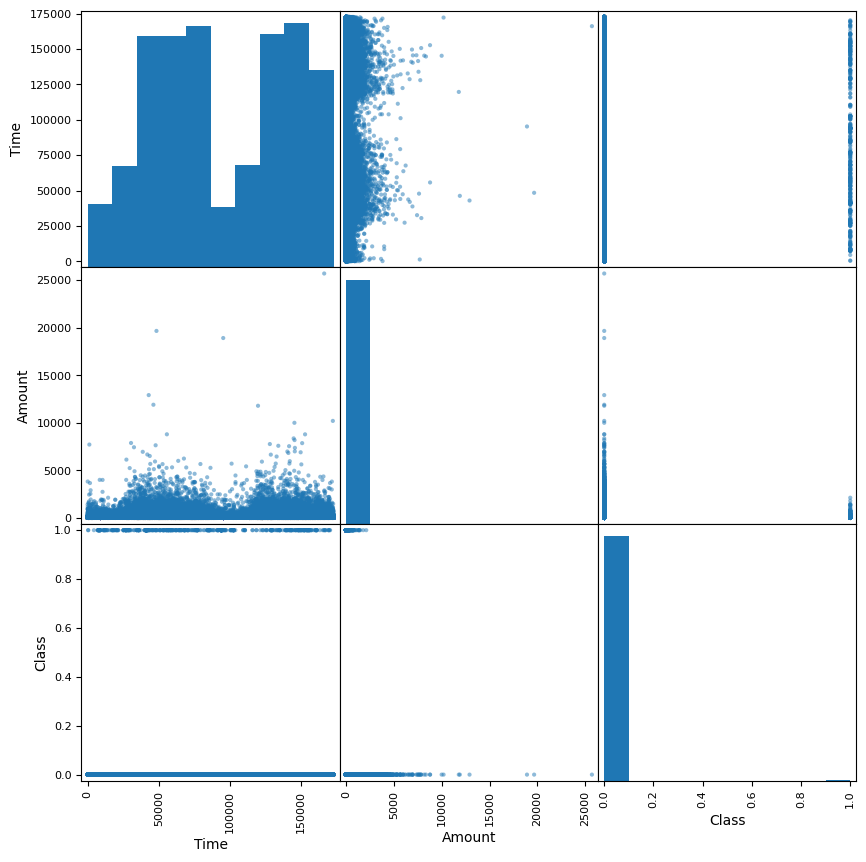

In [37]:
# Create a scatter matrix using only numeric attributes
attributes = ["Time", "Amount", "Class"]
scatter_matrix(fraud_df[attributes], figsize=(10, 10))

<Axes: xlabel='Time', ylabel='Count'>

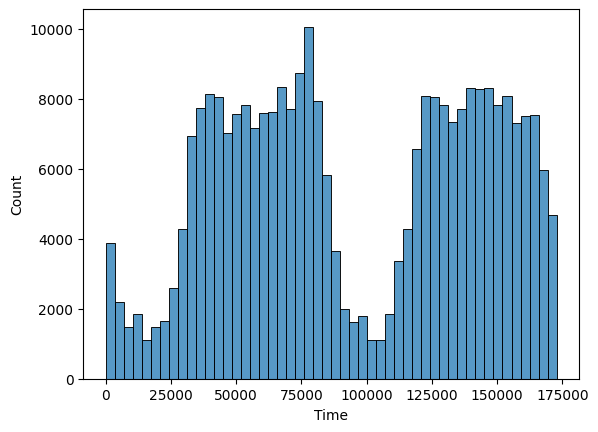

In [38]:
sns.histplot(fraud_df["Time"], bins=50)

<Axes: xlabel='Amount', ylabel='Count'>

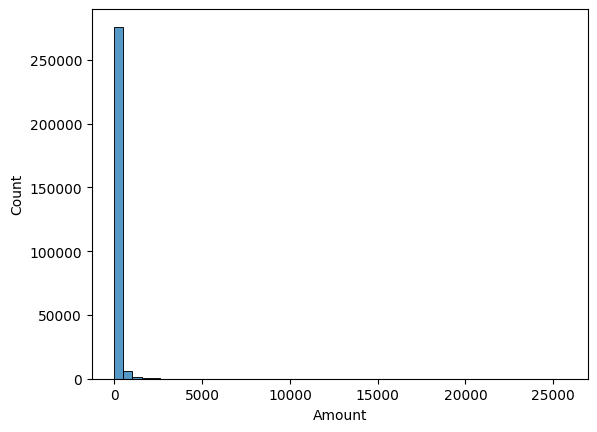

In [39]:
sns.histplot(fraud_df["Amount"], bins=50)

<Axes: xlabel='Amount', ylabel='Count'>

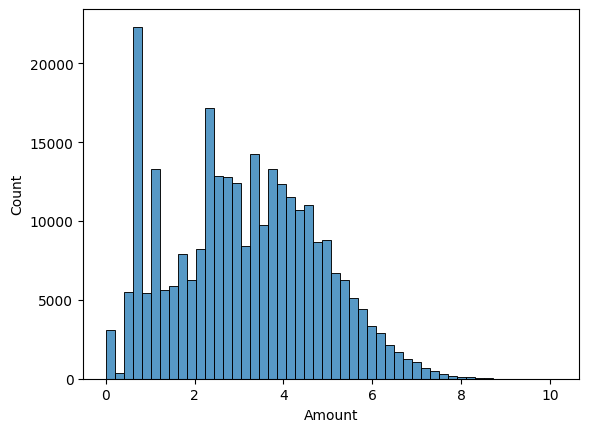

In [40]:
sns.histplot(np.log1p(fraud_df["Amount"]), bins=50)

<Axes: xlabel='Class'>

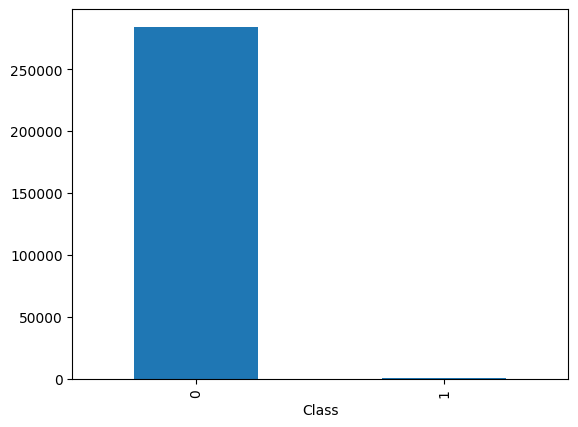

In [41]:
fraud_df["Class"].value_counts().plot(kind="bar")

Text(0.5, 1.0, 'Class Distribution (Proportion)')

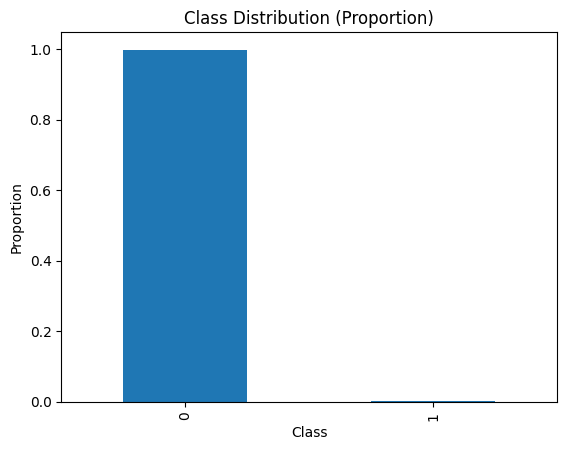

In [42]:
ax = fraud_df["Class"].value_counts(normalize=True).plot(kind="bar")
ax.set_ylabel("Proportion")
ax.set_title("Class Distribution (Proportion)")

<Axes: xlabel='Class', ylabel='Amount'>

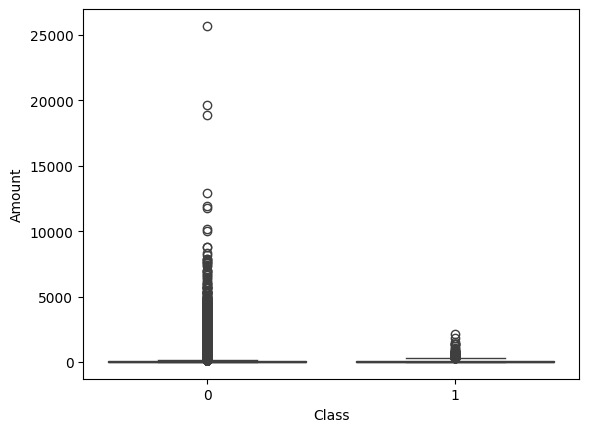

In [43]:
sns.boxplot(x="Class", y="Amount", data=fraud_df)

### Choose features and target, define X and y.

In [44]:
X = fraud_df.drop("Class", axis=1)
y = fraud_df["Class"]

### Split the data into training and test sets using train_test_split.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training Set:", X_train.shape, y_train.shape)
print("Test Set:", X_test.shape, y_test.shape)

Training Set: (227845, 30) (227845,)
Test Set: (56962, 30) (56962,)


### Implement feature scaling and train model.

In [46]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model_train = LogisticRegression(max_iter=1000).fit(X_train_scaled, y_train)

### Evaluate and Report performance.

In [47]:
y_pred = lr_model_train.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[56851    13]
 [   36    62]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



### Evaluate alternate model.

In [49]:
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix:")
print(cm_rf)

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Confusion Matrix:
[[56859     5]
 [   18    80]]

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

